In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

Exploring the dataset

In [3]:
cancer = load_breast_cancer()
print(cancer.feature_names[:])

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [4]:
df = pd.DataFrame( # creates a DataFrame from the breast cancer dataset's features,  
    data = cancer.data, # where each row represents a sample
    columns = cancer.feature_names #and each column represents a feature.
)
df['target']=cancer.target # adds a new column 'target' to the DataFrame, 
#which contains the labels (0 for malignant, 1 for benign) for each sample in the dataset.

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [ ]:
targetValues=df['target'].value_counts() # counts the occurrences of each unique value in the 'target' column of the DataFrame, providing insight into the distribution of malignant and benign cases in the dataset.
targetValues

target
1    357
0    212
Name: count, dtype: int64

In [8]:
df.describe

<bound method NDFrame.describe of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean c

In [9]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

Baseline Model

In [ ]:
#Baseline Model 
X = df.drop('target', axis=1) # creates a new DataFrame X by dropping the 'target' column from the original DataFrame df,
# resulting in a DataFrame that contains only the feature columns (input variables) for model training and testing.
Y= df['target'] # creates a new Series Y by selecting the 'target' column from the original DataFrame df, 
# resulting in a Series that contains only the target labels for model training and testing.

In [ ]:
print(X.shape) # samples (rows) and features (columns)
print(Y.shape) 

(569, 30)
(569,)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
# splits the dataset into training and testing sets, with 80% of the data used for training and 20% for testing, while ensuring reproducibility with a specified random state.

In [13]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
Y_train: (455,)
Y_test : (114,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fits (calculates mean/std) only on training data, then transforms it.
X_test_scaled = scaler.transform(X_test) # the test set is scaled using the training set's mean/std, never its own.

In [ ]:
X_train_scaled_df = pd.DataFrame( # creates a new DataFrame from the scaled training data
    X_train_scaled,
    columns=X_train.columns
)

X_train_scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression() ## trains the logistic regression model on the scaled training data, learning the relationship between features and species labels.

In [ ]:
model.fit(X_train, Y_train) # fits the model on the scaled training data

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test) # uses the trained model to predict species labels for the scaled test data, generating predicted values.
print(y_pred[:10])

[1 0 0 1 1 0 0 0 1 1]


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)
# Calculates the accuracy of the model by comparing the true labels (y_test) with the predicted labels (y_pred).

Accuracy: 0.956140350877193


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(Y_test, y_pred)
print("Precision:", precision)
# Calculates the precision of the model, which is the ratio of true positive predictions to the total predicted positives, averaged across all classes using a weighted approach.

Precision: 0.9459459459459459


In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(Y_test, y_pred)
print("f1_score:", f1)
# Calculates the F1-score of the model, which is the harmonic mean of precision and recall, providing a single metric that balances both, averaged across all classes using a weighted approach.

f1_score: 0.9655172413793104


In [ ]:
from sklearn.metrics import recall_score
recall = f1_score(Y_test, y_pred)
print("recall:", recall)
# Calculates the recall of the model, which is the ratio of true positive predictions to the total actual positives, averaged across all classes using a weighted approach.

recall: 0.9655172413793104


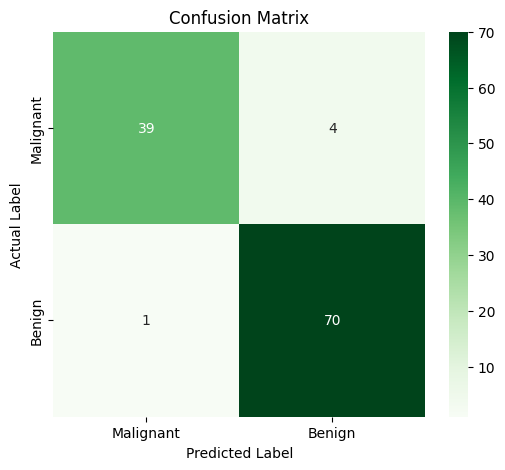

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Hyperparameter Tuning

In [24]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [25]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [26]:
grid_search.fit(X_train, Y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [27]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 100, 'solver': 'liblinear'}


In [28]:
print("Best Cross Validation Score:", grid_search.best_score_)

Best Cross Validation Score: 0.9604395604395604


In [29]:
best_model = grid_search.best_estimator_

In [30]:
y_pred_tuned = best_model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score
tuned_acc = accuracy_score(Y_test, y_pred_tuned)

print("Baseline Accuracy:", accuracy)
print("Tuned Accuracy:", tuned_acc)

Baseline Accuracy: 0.956140350877193
Tuned Accuracy: 0.956140350877193


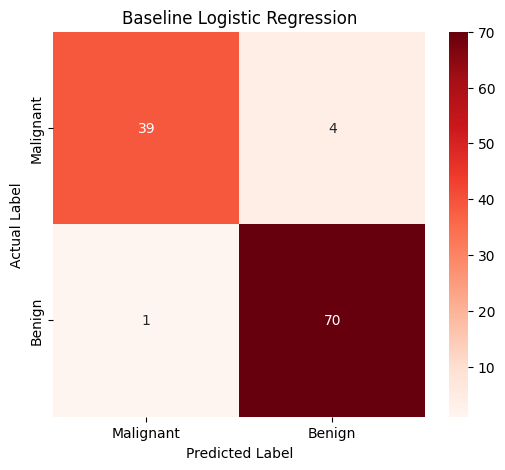

In [32]:
cm_baseline = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.title("Baseline Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

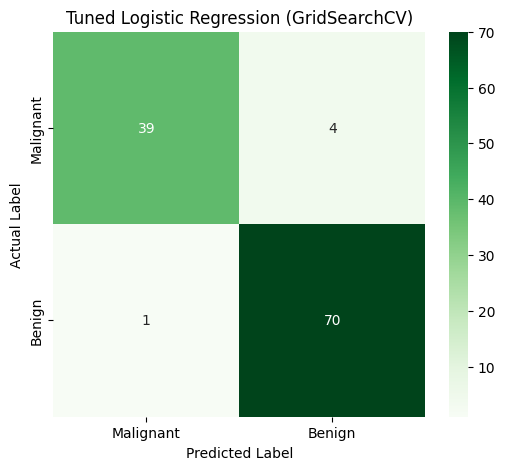

In [33]:
cm_tuned = confusion_matrix(Y_test, y_pred_tuned)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.title("Tuned Logistic Regression (GridSearchCV)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()